<a href="https://colab.research.google.com/github/VooDooPR/tenser-flow/blob/main/PR1_Zayac_%D0%93%D1%83%D1%81%D0%B0%D1%80%D0%BE%D0%B2%D0%9C%D0%9A_%D0%90%D0%94%D0%98%D0%98_25_3_main_ver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


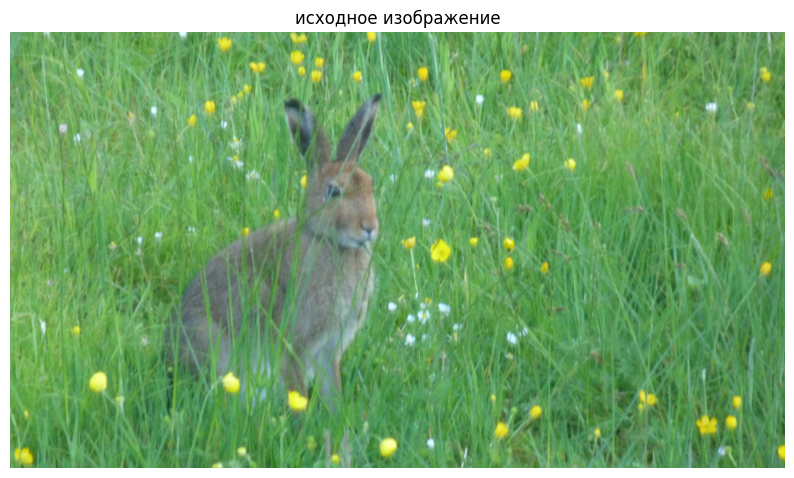

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = "/content/drive/MyDrive/ранх/2 сем/Маш обуч инт вещей/zayac.jpg"

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError("изображение нет")

h, w = image.shape[:2]

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("исходное изображение")
plt.axis("off")
plt.show()

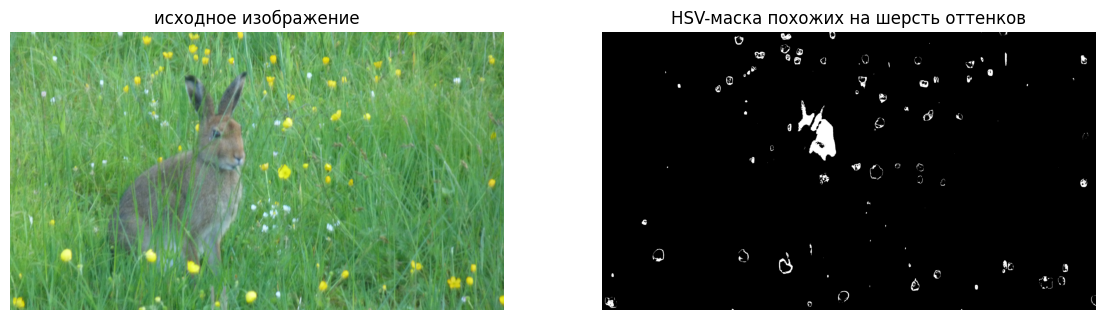

In [ ]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower_fur = np.array([5, 15, 35])
upper_fur = np.array([38, 190, 235])

hsv_mask = cv2.inRange(hsv, lower_fur, upper_fur)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("исходное изображение")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hsv_mask, cmap="gray")
plt.title("HSV-маска похожих на шерсть оттенков")
plt.axis("off")

plt.show()

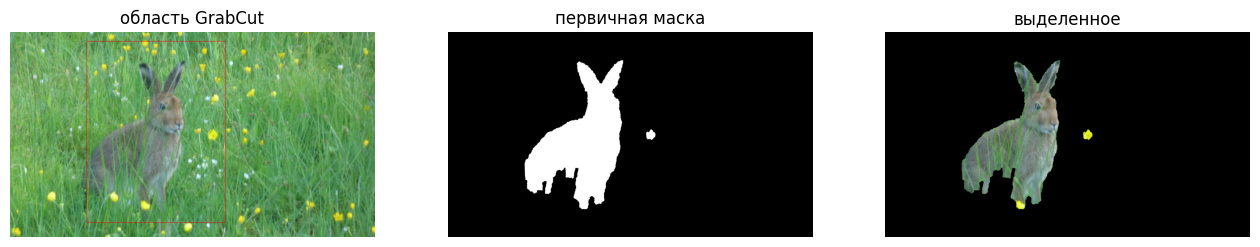

In [ ]:
rect = (
    int(w * 0.21),
    int(h * 0.05),
    int(w * 0.38),
    int(h * 0.88)
)

grabcut_mask = np.zeros((h, w), np.uint8)

bg_model = np.zeros((1, 65), np.float64)
fg_model = np.zeros((1, 65), np.float64)

cv2.grabCut(
    image,
    grabcut_mask,
    rect,
    bg_model,
    fg_model,
    15,
    cv2.GC_INIT_WITH_RECT
)

raw_mask = np.where(
    (grabcut_mask == cv2.GC_FGD) | (grabcut_mask == cv2.GC_PR_FGD),
    255,
    0
).astype(np.uint8)

image_with_rect = image.copy()
x, y, rw, rh = rect
cv2.rectangle(image_with_rect, (x, y), (x + rw, y + rh), (0, 0, 255), 4)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image_with_rect, cv2.COLOR_BGR2RGB))
plt.title("область GrabCut")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(raw_mask, cmap="gray")
plt.title("первичная маска")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(cv2.bitwise_and(image, image, mask=raw_mask), cv2.COLOR_BGR2RGB))
plt.title("выделенное")
plt.axis("off")

plt.show()

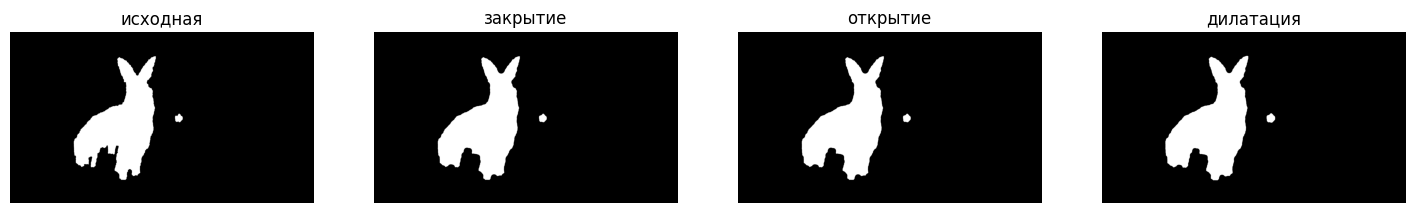

In [ ]:
k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (29, 29))
k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
k_expand = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13, 13))

closed_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE, k_close, iterations=3)
opened_mask = cv2.morphologyEx(closed_mask, cv2.MORPH_OPEN, k_open, iterations=1)
expanded_mask = cv2.dilate(opened_mask, k_expand, iterations=1)

plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(raw_mask, cmap="gray")
plt.title("исходная")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(closed_mask, cmap="gray")
plt.title("закрытие")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(opened_mask, cmap="gray")
plt.title("открытие")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(expanded_mask, cmap="gray")
plt.title("дилатация")
plt.axis("off")

plt.show()

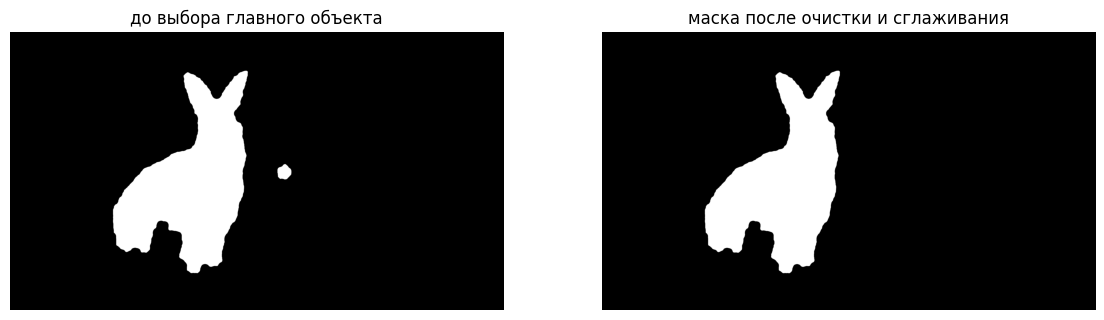

In [ ]:
num, labels, stats, _ = cv2.connectedComponentsWithStats(expanded_mask, 8)

if num > 1:
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    clean_mask = np.where(labels == largest, 255, 0).astype(np.uint8)
else:
    clean_mask = expanded_mask.copy()

clean_mask = cv2.GaussianBlur(clean_mask, (11, 11), 0)
_, clean_mask = cv2.threshold(clean_mask, 95, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(expanded_mask, cmap="gray")
plt.title("до выбора главного объекта")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clean_mask, cmap="gray")
plt.title("маска после очистки и сглаживания")
plt.axis("off")

plt.show()

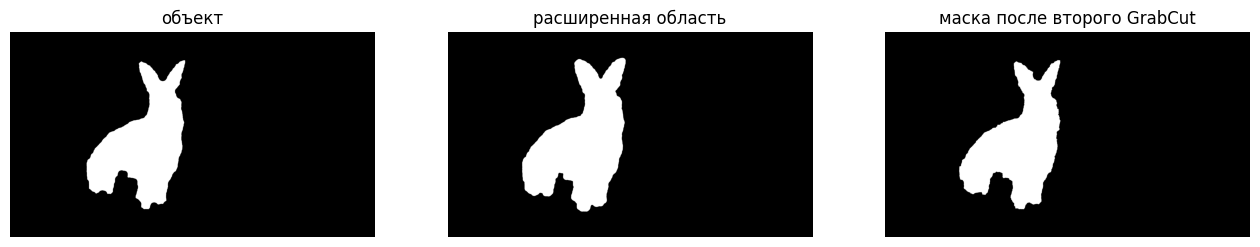

In [ ]:
sure_fg = cv2.erode(
    clean_mask,
    cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15)),
    iterations=1
)

sure_bg = cv2.dilate(
    clean_mask,
    cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (45, 45)),
    iterations=1
)

gc = np.full((h, w), cv2.GC_BGD, dtype=np.uint8)
gc[sure_bg > 0] = cv2.GC_PR_BGD
gc[clean_mask > 0] = cv2.GC_PR_FGD
gc[sure_fg > 0] = cv2.GC_FGD

bg_model = np.zeros((1, 65), np.float64)
fg_model = np.zeros((1, 65), np.float64)

cv2.grabCut(
    image,
    gc,
    None,
    bg_model,
    fg_model,
    8,
    cv2.GC_INIT_WITH_MASK
)

refined_mask = np.where(
    (gc == cv2.GC_FGD) | (gc == cv2.GC_PR_FGD),
    255,
    0
).astype(np.uint8)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(sure_fg, cmap="gray")
plt.title("объект")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sure_bg, cmap="gray")
plt.title("расширенная область")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(refined_mask, cmap="gray")
plt.title("маска после второго GrabCut")
plt.axis("off")

plt.show()

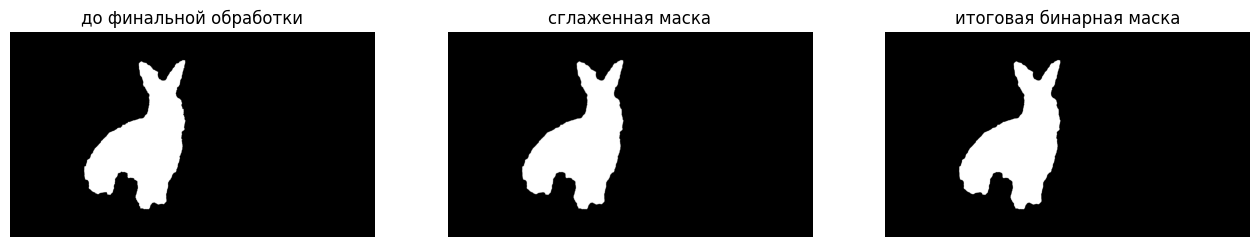

In [ ]:
k_final_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))
k_final_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

final_mask = cv2.morphologyEx(refined_mask, cv2.MORPH_CLOSE, k_final_close, iterations=2)
final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_OPEN, k_final_open, iterations=1)

num, labels, stats, _ = cv2.connectedComponentsWithStats(final_mask, 8)

if num > 1:
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    final_mask = np.where(labels == largest, 255, 0).astype(np.uint8)

blurred_final = cv2.GaussianBlur(final_mask, (9, 9), 0)
_, final_mask = cv2.threshold(blurred_final, 105, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(refined_mask, cmap="gray")
plt.title("до финальной обработки")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blurred_final, cmap="gray")
plt.title("сглаженная маска")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(final_mask, cmap="gray")
plt.title("итоговая бинарная маска")
plt.axis("off")

plt.show()

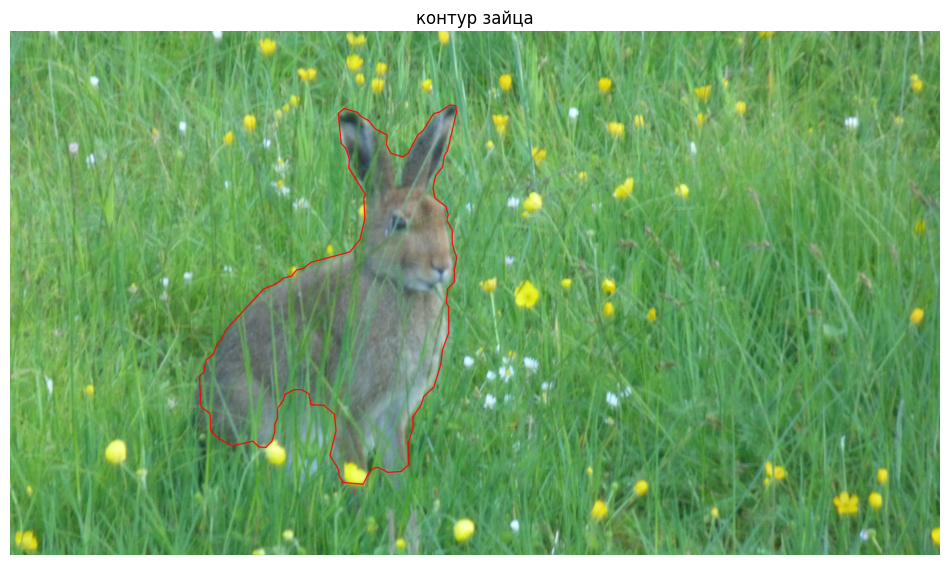

In [ ]:
contours, _ = cv2.findContours(
    final_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

if not contours:
    raise ValueError("Контур не найден")

main_contour = max(contours, key=cv2.contourArea)

epsilon = 0.0009 * cv2.arcLength(main_contour, True)
main_contour = cv2.approxPolyDP(main_contour, epsilon, True)

result = image.copy()

cv2.drawContours(
    result,
    [main_contour],
    -1,
    (0, 0, 255),
    4,
    lineType=cv2.LINE_AA
)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("контур зайца")
plt.axis("off")
plt.show()